In [2]:

import warnings  #This module is used to show warning messages
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd
import numpy as np

In [5]:
#visualazation library
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#evaluation libraries 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [2]:
#deep learning libraries
import tensorflow as tf  #building deep learning models
from tensorflow import keras  #Keras makes model building easy and high-level
from tensorflow.keras import layers  #imports common neural network layers module
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [3]:
#Dataset Loading (digit mnist)
(X_train_digit,y_train_digit),(X_test_digit,y_test_digit) = mnist.load_data()

In [4]:
X_train_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [5]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [8]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 8.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.1 MB 8.0 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 7.7 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 8.0 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.8 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------- ------------- 1.0/1.6 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 5.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -----

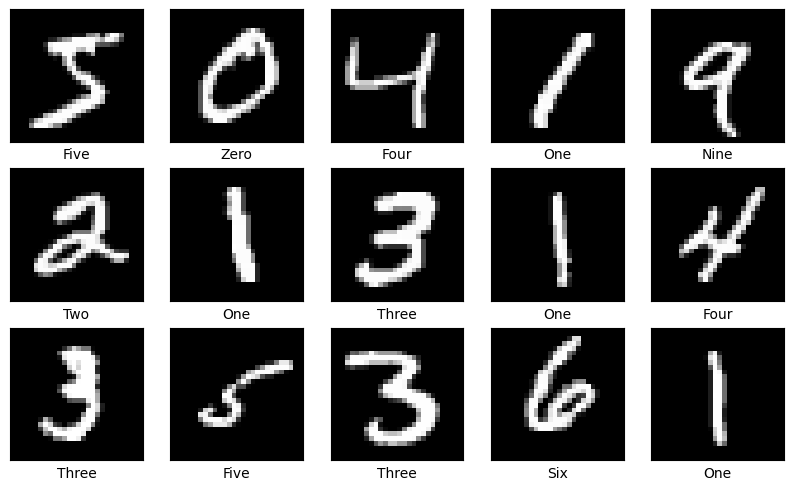

In [9]:
import matplotlib.pyplot as plt

col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [10]:
#checking X_train_digit data 
X_train_digit.shape 

(60000, 28, 28)

In [11]:
X_test_digit.shape

(10000, 28, 28)

In [13]:
#Reduce 3D data to 2D for ANN process
X_train_digit = X_train_digit.reshape(60000,784)
X_test_digit = X_test_digit.reshape(10000,784)

In [14]:
X_train_digit.shape

(60000, 784)

In [15]:
#Checking same with Y train and test data - 1D to 2D 
y_train_digit.shape

(60000,)

In [16]:
y_test_digit[1]

np.uint8(2)

In [17]:
#Encoding digit mnist labels using one hot encoding for ANN
y_train_digit = to_categorical(y_train_digit,num_classes = 10)
y_test_digit = to_categorical(y_test_digit, num_classes = 10)

In [18]:
y_train_digit.shape

(60000, 10)

In [19]:
y_test_digit[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [20]:
#Creating base for neural network
model = keras.Sequential([layers.Dense(256,activation = 'relu',input_shape = (784,)),
                          layers.Dense(64,activation = 'relu'),
                          layers.Dense(64,activation = 'relu'),
                          layers.Dense(10,activation = 'sigmoid')])

C:\Users\premchandar\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
#Denselayer param_num = output_channel_number *(input_channel_num +1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics = ['accuracy'])

In [23]:
#model learning
history  = model.fit(X_train_digit,y_train_digit,batch_size=100,epochs=10,validation_data=(X_test_digit,y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8172 - loss: 1.4178 - val_accuracy: 0.9010 - val_loss: 0.3401
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9295 - loss: 0.2491 - val_accuracy: 0.9379 - val_loss: 0.2287
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9442 - loss: 0.1756 - val_accuracy: 0.9302 - val_loss: 0.2252
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9467 - loss: 0.1532 - val_accuracy: 0.9410 - val_loss: 0.1957
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9528 - loss: 0.1205 - val_accuracy: 0.9403 - val_loss: 0.1751
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9559 - loss: 0.1050 - val_accuracy: 0.9376 - val_loss: 0.1774
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9446 - loss: 0.1024 - val_accuracy: 0.9283 - val_loss: 0.1809
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9456 - loss: 0.0954 - val_accuracy: 0.

In [26]:
import numpy as np

In [27]:
#Here we get the index of maximum value in the encoded vector.
y_predicts = np.argmax(y_predict,axis=1)
y_test_digit_eval = np.argmax(y_test_digit,axis=1)

In [28]:
y_predicts

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [29]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [33]:
!pip install scikit-learn



  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --------------- ------------------------ 3.4/8.9 MB 20.2 MB/s eta 0:00:01
   -------------------- ------------------- 4.5/8.9 MB 10.8 MB/s eta 0:00:01
   ---------------------- ----------------- 5.0/8.9 MB 8.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.9 MB 7.4 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/8.9 MB 6.9 MB/s eta 0:00:01
   ----------------------------------- ---- 7.9/8.9 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 8.7/8.9 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 6.0 MB/s  0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/41.3 MB 7.4 MB/s eta 0

In [37]:
!pip install seaborn

  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.3 MB 33.6 MB/s eta 0:00:01
   --------------- ------------------------ 4.5/11.3 MB 11.7 MB/s eta 0:00:01
   ---------------- ----------------------- 4.7/11.3 MB 7.5 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.3 MB 7.7 MB/s eta 0:00:01
   ------------------------- -------------- 7.3/11.3 MB 7.1 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 6.6 MB/s eta 0:00:01
   ------------------------------- -------- 8.9/11.3 MB 6.4 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.3 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 5.9 MB/s  0:00:01
Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)

   -----------------------------

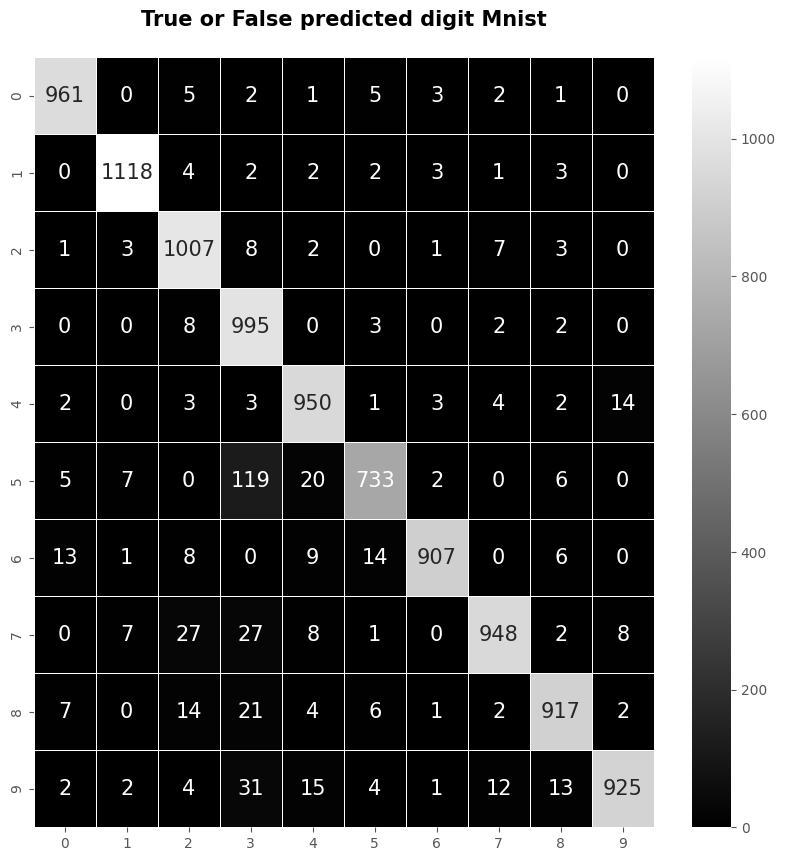

In [38]:
from sklearn.metrics import confusion_matrix
#Confusion matrix for digit mnist
from sklearn.metrics import confusion_matrix
import seaborn as sns
con_mat = confusion_matrix(y_test_digit_eval,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit Mnist\n', fontweight='bold',fontsize=15)
plt.show()

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.93      0.98      0.95      1032
           3       0.82      0.99      0.90      1010
           4       0.94      0.97      0.95       982
           5       0.95      0.82      0.88       892
           6       0.98      0.95      0.97       958
           7       0.97      0.92      0.95      1028
           8       0.96      0.94      0.95       974
           9       0.97      0.92      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.94      0.95     10000
weighted avg       0.95      0.95      0.95     10000



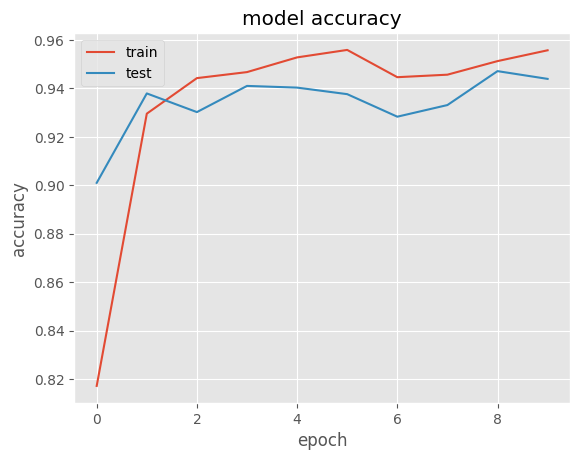

In [40]:
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

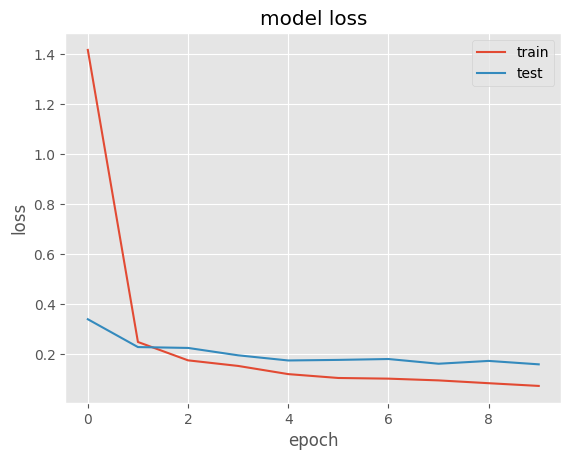

In [41]:
#summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

In [42]:
#single image checking
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single = np.argmax(y_predict_single,axis=1)
y_test_digit_eval = np.argmax(y_test_digit,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


In [43]:
y_predicts_single[0]

np.int64(1)

In [44]:
y_test_digit_eval[2]

np.int64(1)

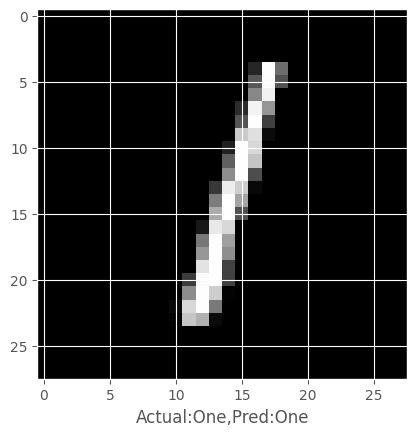

In [45]:
#Names of numbers in the dataset  in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']
#visualization the digits
#plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28),cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[y_test_digit_eval[2]],col_names[y_predicts_single[0]]))
plt.show()